<style>
p { max-width: 80em;}
</style>

## <span style="color:#ce4356">3 </span>  - More dimensions, more realistic problems


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import corner
# good colormaps 
from cmcrameri import cm as cmc
from cmocean import cm as cm
colors = np.vstack([cm.dense([0.25, 0.5, 0.95]),
                    cmc.acton([0.5, 0.85]),
                    cm.matter([0.1, 0.45]),
                    cm.algae([0.5,0.95])])

---
## <span style="color:#ce4356">Example 3.1 </span>  — rabbits on an island

In year 0 a farmer released 100 rabbits on an empty island, and a survey has counted them
twice a year for twelve years. Given the data, predict next year's result.

Start with the simplest model: the population grows in proportion to how many rabbits there
already are,

$$\frac{dN}{dt} = rN$$

One parameter, the growth rate $r$. But rabbits eat, and the island runs out of grass. The
standard fix is **logistic growth** — the same equation with one more parameter, the
carrying capacity $K$, the number of rabbits the island can feed:

$$\frac{dN}{dt} = rN\left(1 - \frac{N}{K}\right)
\qquad\Longrightarrow\qquad
N(t) = \frac{K}{1 + \dfrac{K - N_0}{N_0}\,e^{-rt}}$$

The survey cannot count every rabbit. We assume — or pull out of a hat — that a previous
study measured this uncertainty: a fractional $\sigma \approx 15\%$, so each point carries
its own error $\sigma N_i$. The likelihood is Gaussian, and with two parameters the posterior lives
on a plane:

$$
P\big(r, K \mid \underbrace{\{N_i\}}_{\textstyle\color{#888888}\text{Data}}\big)
\;\propto\;
\underbrace{P(r)\,P(K)}_{\textstyle\color{#888888}\text{priors}}
\;\;
\underbrace{\exp\left[-\tfrac12 \sum_i
\left(\frac{N_i - N(t_i;\, r, K)}{\sigma N_i}\right)^{\!2}\right]}_{\textstyle\color{#888888}\text{likelihood}}
$$

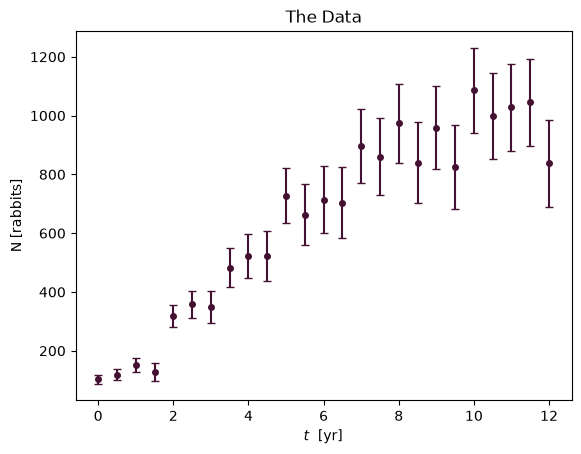

In [2]:
t_survey = np.arange(0, 12.5, 0.5)
N_survey = np.array([103, 118, 151, 128, 318, 358, 349, 483, 522, 522, 728, 663, 714,
                     704, 897, 860, 974, 839, 958, 826, 1086, 1000, 1028, 1045, 838])
sig_survey = np.array([15, 19, 24, 30, 38, 46, 55, 65, 75, 85, 95, 104, 113,
                       120, 126, 131, 135, 138, 141, 143, 145, 146, 147, 148, 148])
N0 = 100.0                       # released in year 0

plt.errorbar(t_survey, N_survey, sig_survey, fmt="o", ms=4, capsize=3, color=colors[2])
plt.xlabel("$t$  [yr]"); plt.ylabel("N [rabbits]"); plt.grid(False)
plt.title('The Data')
plt.show()

Judiciously chosen flat priors: $r \in [0.45, 0.72]$ and $K \in [750, 1200]$.

In [3]:
def logistic(t, r, K, N0=N0):
    return K / (1 + (K - N0) / N0 * np.exp(-np.multiply.outer(r, t)))

r_grid = np.linspace(0.45, 0.72, 300)
K_grid = np.linspace(750, 1200, 300)

# flat priors on both, so posterior = likelihood.  Log space, then exponentiate.
log_posterior = np.array([-0.5 * (((N_survey - logistic(t_survey, r_grid, K)) / sig_survey) ** 2).sum(-1)
                          for K in K_grid])
posterior = np.exp(log_posterior)
posterior /= posterior.sum()         

### <span style="color:#ce4356">a) </span> The joint posterior and its marginals

Joint posterior — $P(r, K \mid \text{Data})$ — the full surface, both parameters at once.

Marginal — $P(K \mid \text{Data}) = \int P(r, K \mid \text{Data})\,dr$ — integrate (marginalise)
the other parameter away.

Conditional — $P(K \mid r=r_0, \text{Data}) \propto P(r_0, K \mid \text{Data})$ —
fix the other parameter, take a slice and renormalise.

The usual way to show a multi-parameter posterior is a `corner` plot:

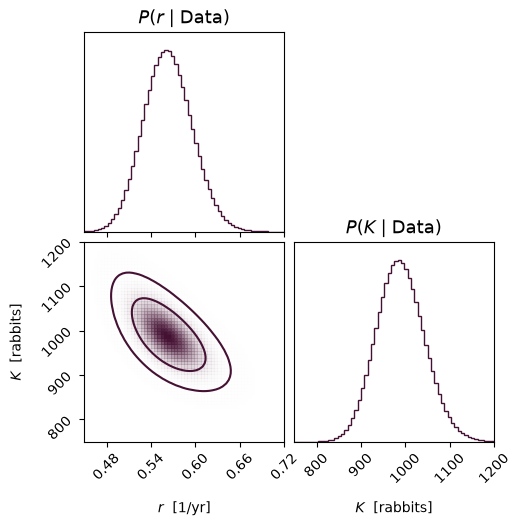

In [4]:
R_mesh, K_mesh = np.meshgrid(r_grid, K_grid)

fig = corner.corner(np.column_stack([R_mesh.ravel(), K_mesh.ravel()]),
                    weights=posterior.ravel(),
                    labels=[r"$r$  [1/yr]", r"$K$  [rabbits]"],color=colors[2],
                    # corner takes samples; the weights argument lets us pass a grid instead
                    plot_datapoints=False, bins=60, levels=(0.68, 0.95))

axes = np.array(fig.axes).reshape((2, 2))
for i, title in enumerate([r"$P(r \mid \mathrm{Data})$", r"$P(K \mid \mathrm{Data})$"]):
    axes[i, i].set_title(title, fontsize=13)

plt.show()

The contours are tilted: $r$ and $K$ are correlated, so knowing one changes what you would
believe about the other. The corner plot is the standard way to show the correlations in a
posterior, and it generalises to any number of parameters.

### <span style="color:#ce4356">b) </span> Nuisance parameters

If we only care about the rate, $K$ becomes a **nuisance parameter** — the model needs it,
we do not want to report it. Integrating it out gives an honest uncertainty on $r$, because
$K$'s uncertainty is carried into the answer rather than ignored. The marginal is wider
than any slice through the joint.

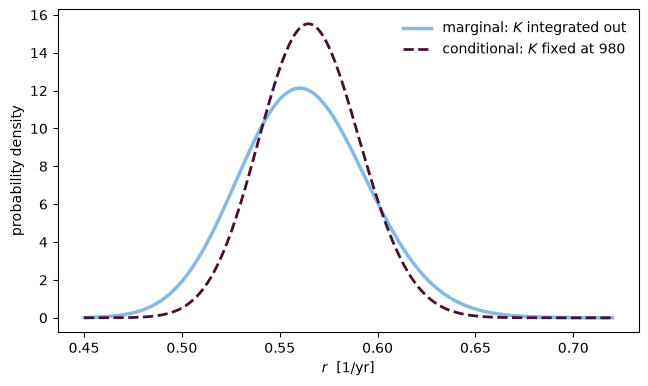

In [5]:
pick_K = 980                                   # fix K here for the conditional

marginal_r = posterior.sum(axis=0)                    # integrate K away
i_pick = np.abs(K_grid - pick_K).argmin()             # nearest grid cell
conditional_r = posterior[i_pick] / posterior[i_pick].sum()

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(r_grid, marginal_r / np.trapezoid(marginal_r, r_grid), lw=2.5,
        label="marginal: $K$ integrated out", color=colors[0])
ax.plot(r_grid, conditional_r / np.trapezoid(conditional_r, r_grid), "--", lw=2,
        label=f"conditional: $K$ fixed at {K_grid[i_pick]:.0f}", color=colors[2])
ax.set_xlabel("$r$  [1/yr]"); ax.set_ylabel("probability density")
ax.grid(False); ax.legend(frameon=False)
plt.show()

### <span style="color:#ce4356">c) </span> Back to the data and prediction

Inference gives a distribution over parameters. Each pair $(r, K)$ is one curve in the
$N$–$t$ plane, and the posterior says how much weight that curve carries. Here the priors
are flat, so the weight is simply the likelihood — *how well the curve explains the data*.

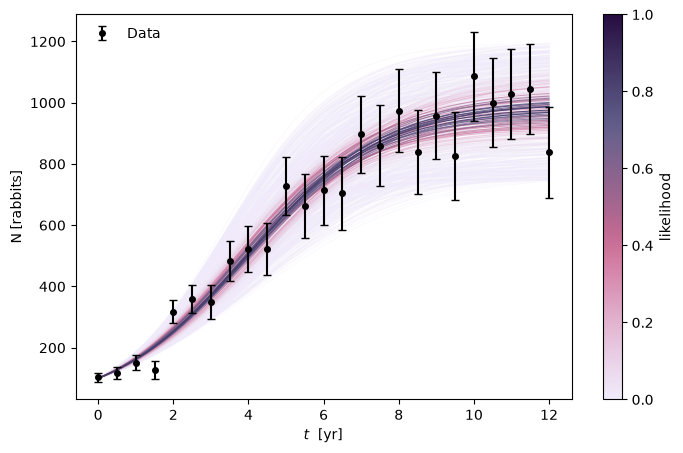

In [6]:
rng = np.random.default_rng(0)
sel = rng.choice(posterior.size, size=500, replace=False)

r_sub = R_mesh.ravel()[sel]
K_sub = K_mesh.ravel()[sel]
w_sub = posterior.ravel()[sel]
w_sub = w_sub / w_sub.max()
order = np.argsort(w_sub)                      # draw the likely ones last, on top

t_hair = np.linspace(0, 12, 150)
curves_hair = K_sub[:, None] / (1 + (K_sub[:, None] - N0) / N0 * np.exp(-np.outer(r_sub, t_hair)))
cmap = cmc.acton_r
fig, ax = plt.subplots(figsize=(8, 5))
for i in order:
    ax.plot(t_hair, curves_hair[i], lw=0.7, color=cmap(0.85 * w_sub[i]), alpha=0.3 + 0.6 * w_sub[i])

ax.errorbar(t_survey, N_survey, sig_survey, fmt="o", ms=4, capsize=3,
            color="k", zorder=20, label="Data")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
fig.colorbar(sm, ax=ax, label="likelihood")
ax.set_xlabel("$t$  [yr]"); ax.set_ylabel("N [rabbits]")
ax.grid(False); ax.legend(frameon=False, loc=2)
plt.show()

### <span style="color:#ce4356">d) </span> Credible intervals

A **credible interval** is a range holding a fraction, e.g. 68%, of the posterior probability:

$$\int_a^b P(\theta \mid \text{Data})\,d\theta = 0.68$$

The interval is not unique — there are several conventions:

- **equal-tailed (quantile)** — cut 16% from each tail, leaving the stated 68% in the middle.
- **highest posterior density (HPD)** — the *shortest* interval holding 68%.

For a symmetric, single-peaked posterior they coincide. Not to be confused with a
*confidence* interval (as in my phd thesis) — a frequentist construction.

The usual choices are 68% and 95%, called 1 and 2 sigma after the Gaussian.

In [7]:
t_fine = np.linspace(0, 13., 110)
r_all, K_all, w_all = R_mesh.ravel(), K_mesh.ravel(), posterior.ravel()

# one curve per grid cell
curves = K_all[:, None] / (1 + (K_all[:, None] - N0) / N0 * np.exp(-np.outer(r_all, t_fine)))

# at each time, the weighted quantiles across all those curves
lo95, lo68, med, hi68, hi95 = np.array([np.quantile(c, [0.025, 0.16, 0.5, 0.84, 0.975],
                                                    weights=w_all, method="inverted_cdf")
                                        for c in curves.T]).T

# same curves, equal weights = what the flat prior alone predicted
prior95 = np.array([np.quantile(c, [0.025, 0.975], method="inverted_cdf")
                    for c in curves.T]).T

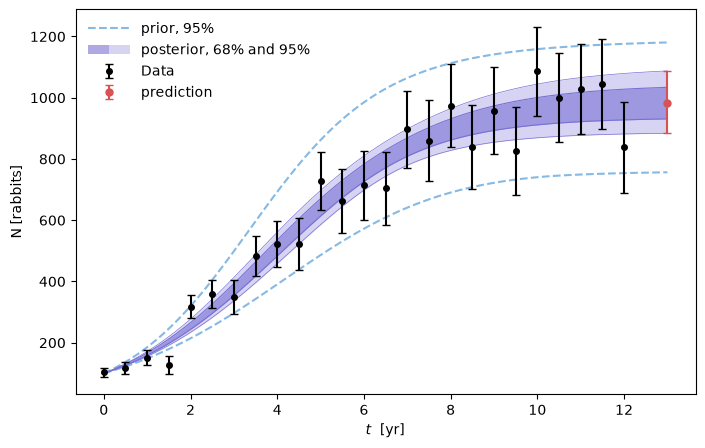

In [8]:
from matplotlib.legend_handler import HandlerTuple

fig, ax = plt.subplots(figsize=(8, 5))

h_prior, = ax.plot(t_fine, prior95[0], "--", color=colors[0], lw=1.5)
ax.plot(t_fine, prior95[1], "--", color=colors[0], lw=1.5)

h95 = ax.fill_between(t_fine, lo95, hi95, alpha=0.30, color=colors[1], lw=0)
h68 = ax.fill_between(t_fine, lo68, hi68, alpha=0.6, color=colors[1], lw=0)
ax.plot(t_fine, lo95, "-", color=colors[1], lw=0.5);   ax.plot(t_fine, hi95, "-", color=colors[1], lw=0.5)
ax.plot(t_fine, lo68, "-", color=colors[1], lw=0.8); ax.plot(t_fine, hi68, "-", color=colors[1], lw=.8)

h_data = ax.errorbar(t_survey, N_survey, sig_survey, fmt="o", ms=4, capsize=3, color="k")

h_pred = ax.errorbar(t_fine[-1], med[-1], yerr=[[med[-1] - lo95[-1]], [hi95[-1] - med[-1]]],
                     fmt="o", ms=5, capsize=3, color=colors[-3], zorder=25)

ax.legend([h_prior, (h68, h95), h_data, h_pred],
          ["prior, 95%", "posterior, 68% and 95%", "Data", "prediction"],
          handler_map={tuple: HandlerTuple(ndivide=None, pad=0)},
          handlelength=3.0, frameon=False)

ax.set_xlabel("$t$  [yr]"); ax.set_ylabel("N [rabbits]")
ax.grid(False)
plt.show()

A slice at 13 years, answering the question we asked — our best prediction for the
measurement next year.

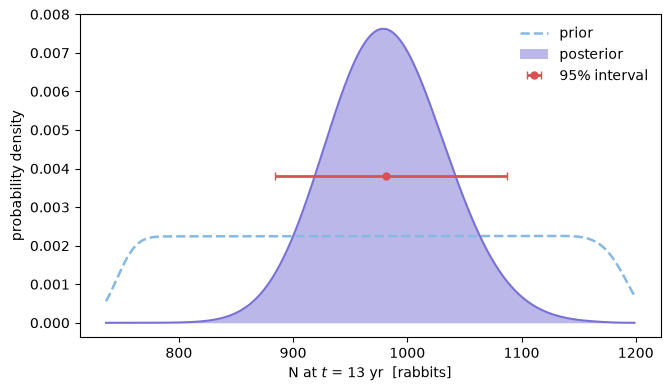

In [9]:
from scipy.stats import gaussian_kde

t_pred = 13.0
N_pred = K_all / (1 + (K_all - N0) / N0 * np.exp(-r_all * t_pred))

x = np.linspace(N_pred.min(), N_pred.max(), 400)
post_d  = gaussian_kde(N_pred, weights=w_all)(x)      # weighted by the posterior
prior_d = gaussian_kde(N_pred)(x)                     # equal weights = flat prior

lo95_pred, med_pred, hi95_pred = np.quantile(N_pred, [0.025, 0.5, 0.975],
                                             weights=w_all, method="inverted_cdf")

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(x, prior_d, "--", lw=1.8, color=colors[0], label="prior")
ax.plot(x, post_d, color=colors[1])
ax.fill_between(x, post_d, alpha=0.5, color=colors[1], lw=0, label="posterior")

ax.errorbar(med_pred, 0.5 * post_d.max(),
            xerr=[[med_pred - lo95_pred], [hi95_pred - med_pred]],
            fmt="o", ms=5, capsize=3,lw=2., color=colors[6], zorder=25, label="95% interval")

ax.set_xlabel(f"N at $t$ = {t_pred:.0f} yr  [rabbits]"); ax.set_ylabel("probability density")
ax.grid(False); ax.legend(frameon=False)
plt.show()

### What to take from this

- In multi-parameter inference the final answer is the joint posterior with all the
  correlations — from which CIs and a prediction can be read off.

- Marginalisation is a way of implementing the uncertainty of the nuisance parameter.

---
## <span style="color:#ce4356">e) </span>  — comparing two models

Assume we have another, simpler model — pure exponential growth **(exp)**, no limit on the grass,
$N = N_0 e^{rt}$ — and ask which model the data prefer.

Intuitively, give each model one unit of prior probability to spread over its own parameters:

$$\int P(r)\,dr = 1 \qquad\qquad \iint P(r)\,P(K)\,dr\,dK = 1$$

and then ask how much of that unit survives contact with the data. This is precisely the
marginalised likelihood — the evidence — the denominator in Bayes' theorem:

$$P(\text{Data} \mid \text{exp}) = \int P(\text{Data} \mid r)\,P(r)\,dr$$

$$P(\text{Data} \mid \text{logistic}) = \iint P(\text{Data} \mid r, K)\,P(r)\,P(K)\,dr\,dK$$

The ratio is the **Bayes factor**

$$B = \frac{P(\text{Data} \mid \text{logistic})}{P(\text{Data} \mid \text{exp})}$$

Note that the priors must now be **proper**, normalised to 1. In this example we never bothered:
a flat prior gives just a constant, which cancels between the numerator and the denominator.
Between two models it does not cancel.

Prior knowledge about the models themselves enters through the **prior odds**:

$$
\underbrace{\frac{P(\text{logistic} \mid \text{Data})}{P(\text{exp} \mid \text{Data})}}_{\textstyle\color{#888888}\text{posterior odds}}
\;=\;
\underbrace{B}_{\textstyle\color{#888888}\text{Bayes factor}}
\;\times\;
\underbrace{\frac{P(\text{logistic})}{P(\text{exp})}}_{\textstyle\color{#888888}\text{prior odds}}
$$

Here $P(\text{logistic})$ and $P(\text{exp})$ are priors on the **models**, not on the parameters
inside them. Being agnostic,
$P(\text{logistic}) = P(\text{exp}) = 0.5$, the prior odds are 1, and $B$ is the posterior odds.

In [10]:
def exponential(t, r, N0=N0):
    return N0 * np.exp(np.multiply.outer(r, t))

r_cmp = np.linspace(0.05, 0.80, 300)      # same flat prior on r for both models
K_cmp = np.linspace(200, 3000, 300)       # logistic only

# constant part of the Gaussian, kept so each evidence is a real density over the data
log_norm = -0.5 * len(N_survey) * np.log(2 * np.pi) - np.log(sig_survey).sum()

log_like_exp = -0.5 * (((N_survey - exponential(t_survey, r_cmp)) / sig_survey) ** 2).sum(-1) + log_norm
log_like_log = np.array([-0.5 * (((N_survey - logistic(t_survey, r_cmp, K)) / sig_survey) ** 2).sum(-1)
                         for K in K_cmp]) + log_norm

# flat priors, each normalised over its own box, so both integrate to 1
prior_r = 1 / (r_cmp[-1] - r_cmp[0])
prior_K = 1 / (K_cmp[-1] - K_cmp[0])

# the evidence: likelihood x prior, integrated over the parameters of that model
evidence_exp = np.trapezoid(np.exp(log_like_exp) * prior_r, r_cmp)
evidence_log = np.trapezoid(np.trapezoid(np.exp(log_like_log) * prior_r * prior_K, r_cmp, axis=1), K_cmp)
bayes_factor = evidence_log / evidence_exp

print(f"P(Data | exp)      = {evidence_exp:.2e}")
print(f"P(Data | logistic) = {evidence_log:.2e}")
print(f"B = {bayes_factor:.1e}   in favour of the logistic")

P(Data | exp)      = 1.39e-98
P(Data | logistic) = 1.42e-64
B = 1.0e+34   in favour of the logistic


One interpretation — Jeffreys' scale

| $B$ | Strength of evidence |
|:---|:---|
| $< 10^{0}$ | Negative (supports the other model) |
| $10^{0}$ to $10^{1/2}$ | Barely worth mentioning |
| $10^{1/2}$ to $10^{1}$ | Substantial |
| $10^{1}$ to $10^{3/2}$ | Strong |
| $10^{3/2}$ to $10^{2}$ | Very strong |
| $> 10^{2}$ | Decisive |

Ours, $10^{34}$, is quite decisive. 

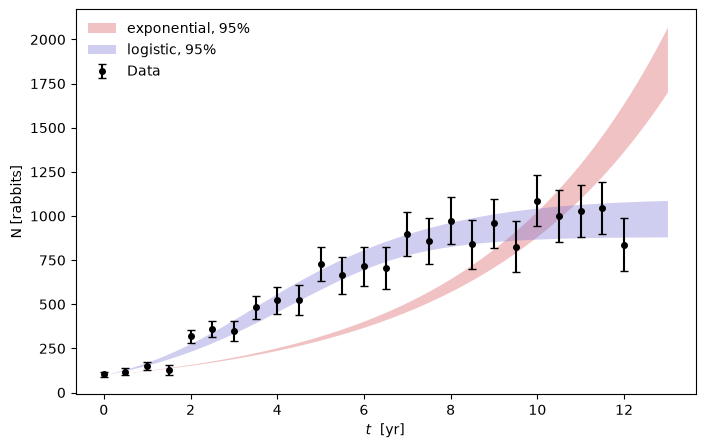

In [11]:
posterior_exp = np.exp(log_like_exp - log_like_exp.max());  posterior_exp /= posterior_exp.sum()
posterior_log = np.exp(log_like_log - log_like_log.max());  posterior_log /= posterior_log.sum()

R_cmp, K_cmp_mesh = np.meshgrid(r_cmp, K_cmp)
curves_exp = exponential(t_fine, r_cmp)
curves_log = logistic(t_fine, R_cmp.ravel(), K_cmp_mesh.ravel()[:, None])

lo_exp, hi_exp = np.array([np.quantile(c, [0.025, 0.975], weights=posterior_exp,
                                       method="inverted_cdf") for c in curves_exp.T]).T
lo_log, hi_log = np.array([np.quantile(c, [0.025, 0.975], weights=posterior_log.ravel(),
                                       method="inverted_cdf") for c in curves_log.T]).T

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(t_fine, lo_exp, hi_exp, alpha=0.35, color=colors[6], lw=0, label="exponential, 95%")
ax.fill_between(t_fine, lo_log, hi_log, alpha=0.35, color=colors[1], lw=0, label="logistic, 95%")
ax.errorbar(t_survey, N_survey, sig_survey, fmt="o", ms=4, capsize=3, color="k", label="Data")

ax.set_xlabel("$t$  [yr]"); ax.set_ylabel("N [rabbits]")
ax.grid(False); ax.legend(frameon=False)
plt.show()

There are also ways to ask whether a model reproduces the data at all, without a second model
to compare it against — **posterior predictive checks**. And again, in my experience they are
rarely used in astro (though perhaps they should be), and for now they are outside the
scope of an introductory course.